In [67]:
# 获取数据集
import pandas as pd
from sklearn.datasets import fetch_openml
boston = fetch_openml(name='boston', version=1)

boston1 = pd.DataFrame(boston.data,columns=boston.feature_names)
boston1[boston.target_names[0]] = boston.target
boston = boston1

In [68]:


boston.dropna(inplace=True) #删除有缺失的样本

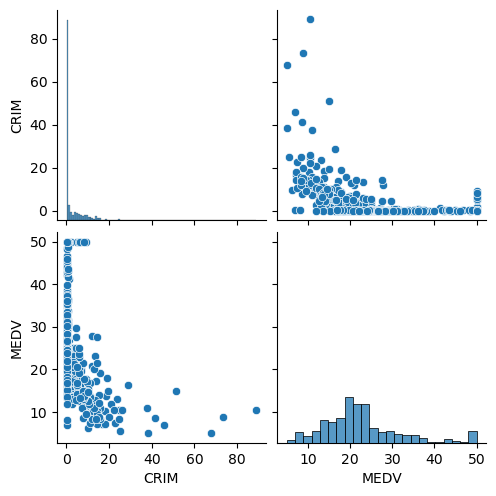

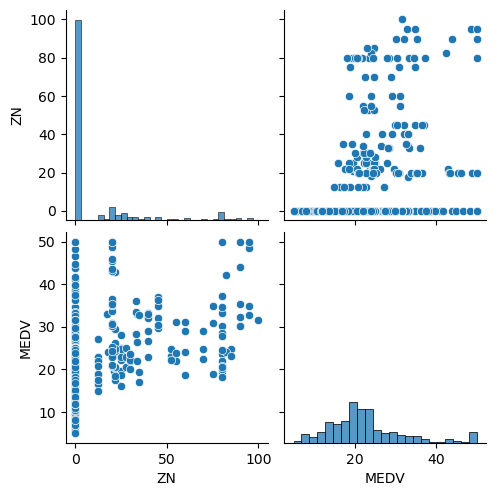

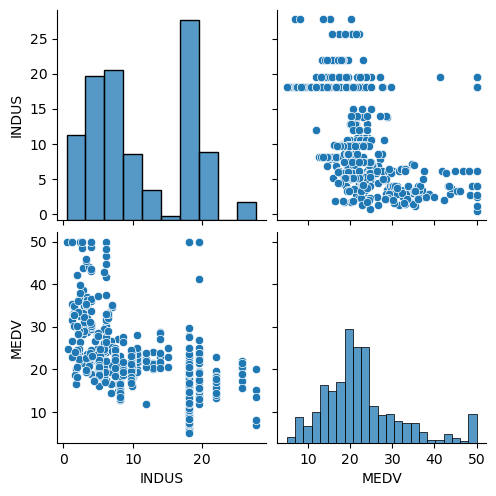

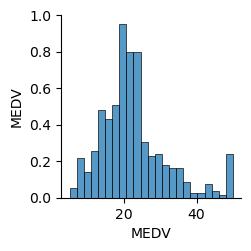

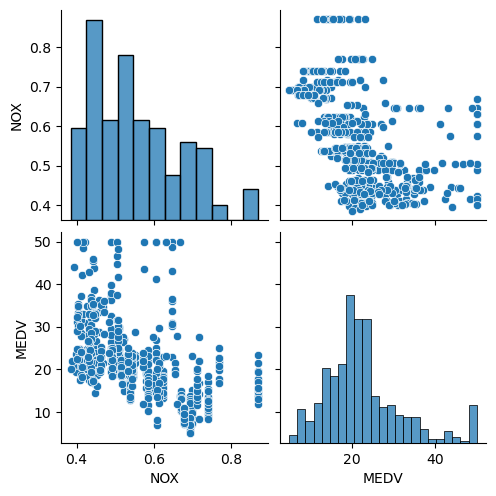

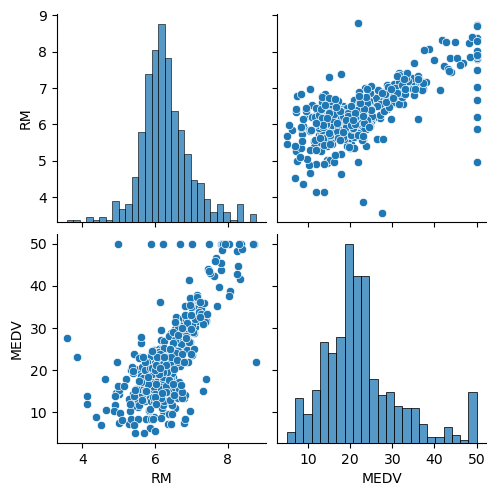

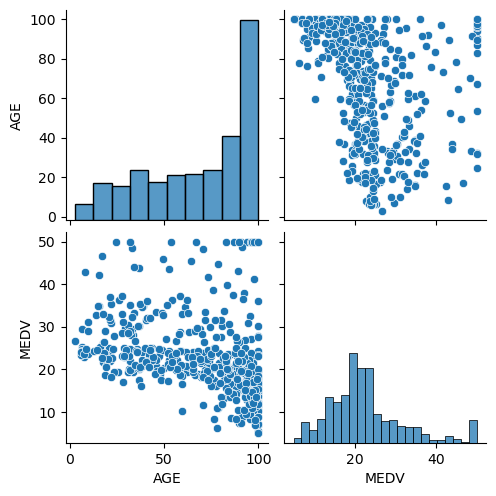

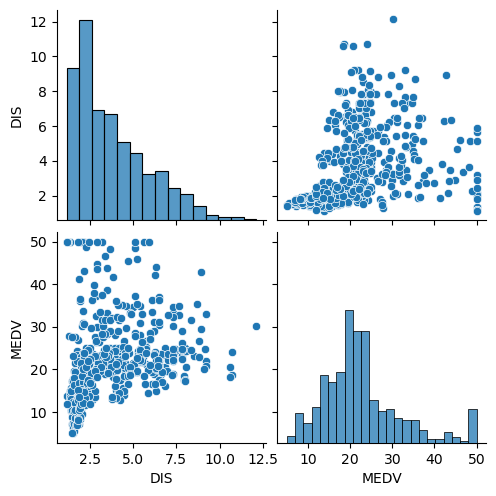

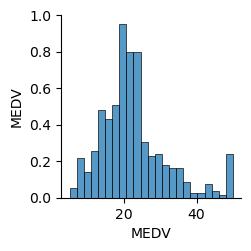

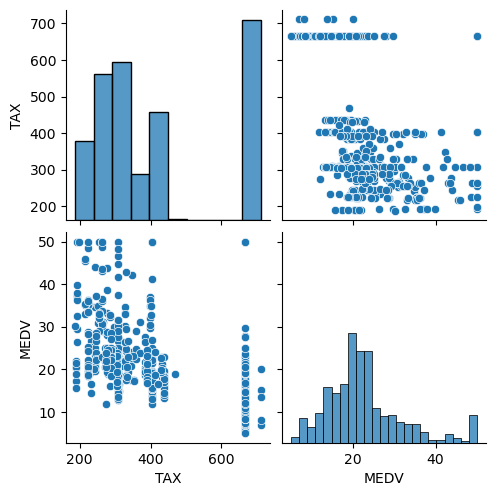

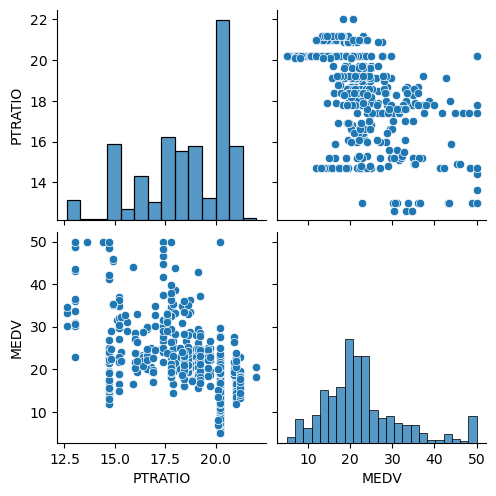

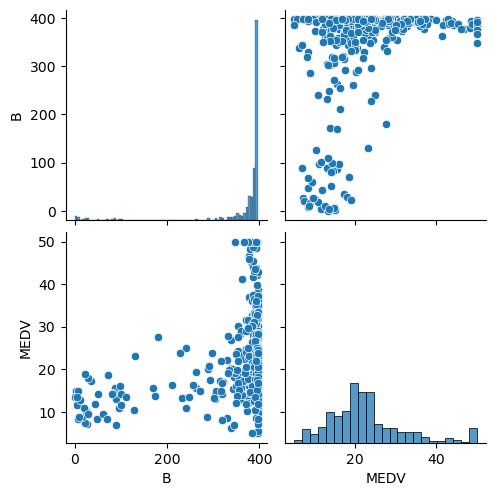

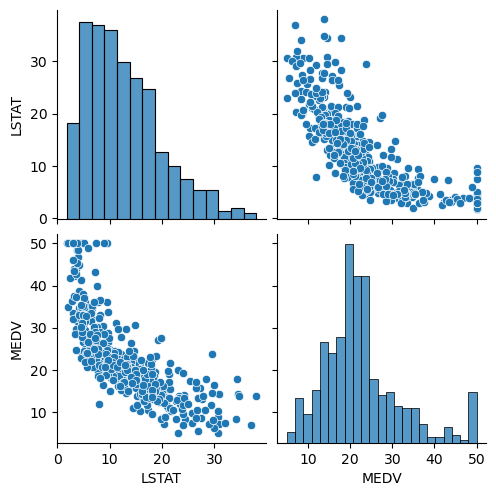

In [69]:

import seaborn as sn
for id in boston.columns[:-1]:
    sn.pairplot(boston[[id,boston.columns[-1]]])


In [70]:
# 划分数据集
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(boston.iloc[:,:-1],boston['MEDV'],random_state=22)

In [71]:
# 无量纲化 标准化
from sklearn.preprocessing import StandardScaler
transfer = StandardScaler()
x_train = transfer.fit_transform(x_train)
x_test = transfer.transform(x_test)
x_train

array([[-0.20918739, -0.52054534,  1.24477931, ..., -1.72807526,
        -1.35897227, -0.08447646],
       [-0.43088174,  0.3974553 , -0.7606374 , ...,  0.30003249,
         0.24261973, -1.25661718],
       [-0.41899191,  0.3140007 , -0.59985326, ...,  0.0695657 ,
         0.36670935,  0.03342307],
       ...,
       [-0.45463067,  2.4003658 , -1.28976339, ..., -1.6819819 ,
         0.3903914 , -0.91662782],
       [-0.37833557, -0.52054534,  1.582426  , ...,  1.26799301,
         0.33574053, -0.22431079],
       [ 1.09172307, -0.52054534,  1.02845156, ...,  0.80705943,
         0.45511517,  3.0179264 ]])

In [72]:
# 预估器
from sklearn.linear_model import LinearRegression
estimator = LinearRegression()
# 得出模型
estimator.fit(x_train,y_train)
# 模型评估
print('正规方程-权重系数:',estimator.coef_)
print('正规方程-偏置:',estimator.intercept_)

正规方程-权重系数: [-0.64817766  1.14673408 -0.05949444  0.74216553 -1.95515269  2.70902585
 -0.07737374 -3.29889391  2.50267196 -1.85679269 -1.75044624  0.87341624
 -3.91336869]
正规方程-偏置: 22.621372031662272


In [73]:
# 预估器 随机梯度下降
from sklearn.linear_model import SGDRegressor
sdg = SGDRegressor()
# 得出模型
sdg.fit(x_train,y_train)
# 模型评估
print('梯度下降-权重系数:',sdg.coef_)
print('梯度下降-偏置:',sdg.intercept_)

梯度下降-权重系数: [-0.59358282  1.03199999 -0.32211369  0.76546222 -1.85760699  2.7429366
 -0.12784244 -3.23964776  1.94297418 -1.22284487 -1.73735606  0.86069712
 -3.90104115]
梯度下降-偏置: [22.62411204]


In [74]:
y_predict = sdg.predict(x_test)
y_predict

array([28.23164053, 31.61405992, 21.38283697, 32.64927085, 20.10755056,
       18.99738791, 21.33002047, 19.48445521, 19.65919229, 32.79660329,
       21.30917557, 27.3506659 , 15.57679255, 19.84624839, 36.86493043,
       18.82145017,  9.46012557, 18.56804888, 30.70430929, 24.33961801,
       18.9870118 , 34.06967769, 29.55630419, 17.4307642 , 34.82557752,
       26.61200935, 34.57232975, 27.44289792, 19.02407091, 15.46027953,
       30.83555318, 14.93394752, 37.48636513,  8.1295052 , 16.33298832,
       16.98549892,  7.50508288, 19.85210753, 40.49000379, 29.06106594,
       25.26146006, 17.71443104, 38.86770467,  6.76452265, 21.6615297 ,
       25.17667908, 20.59758552, 20.53279465, 17.1279997 , 26.10680051,
        9.30440733, 27.3451512 , 30.5786946 , 16.55082295,  9.42588318,
       35.4887219 , 31.92360762, 22.60635716, 17.60319981, 21.93391548,
       23.6506792 , 24.05935763, 20.26864488, 38.29993913, 25.39080241,
       19.6558138 , 13.9596785 ,  6.69483793, 42.13754281, 21.92

In [75]:
# 岭回归对波士顿房价的预测
from sklearn.linear_model import Ridge

# 建立模型
estimator = Ridge(max_iter=10000,alpha=1)
estimator.fit(x_train, y_train)
# 得出模型
print("岭回归-权重系数：\n",estimator.coef_)
print("岭回归-偏置：\n",estimator.intercept_)
# 模型评估
y_predict = estimator.predict(x_test)
print("预测房价：\n",y_predict)





岭回归-权重系数：
 [-0.63591916  1.12109181 -0.09319611  0.74628129 -1.91888749  2.71927719
 -0.08590464 -3.25882705  2.41315949 -1.76930347 -1.74279405  0.87205004
 -3.89758657]
岭回归-偏置：
 22.621372031662272
预测房价：
 [28.22119941 31.49858594 21.14690941 32.64962343 20.03976087 19.07187629
 21.11827061 19.61935024 19.64669848 32.83666525 21.01034708 27.47939935
 15.55875601 19.80406014 36.86415472 18.79442579  9.42343608 18.5205955
 30.67129766 24.30659711 19.07820077 34.08772738 29.77396117 17.50394928
 34.87750492 26.52508961 34.65566473 27.42939944 19.08639183 15.04854291
 30.84974343 15.76894723 37.18814441  7.81864035 16.27847433 17.15510852
  7.46590141 19.98474662 40.55565604 28.96103939 25.25570196 17.7598197
 38.78171653  6.87935126 21.76805062 25.25888823 20.47319256 20.48808719
 17.24949519 26.11755181  8.61005188 27.47070495 30.57806886 16.57080888
  9.42312214 35.50731907 32.20467352 21.93128073 17.62011278 22.08454636
 23.50121152 24.08248876 20.16840581 38.47001591 24.69276673 19.76